# 1. Importing Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Machine learning model
import lightgbm as lgb

# For splitting data into training and testing sets
from sklearn.model_selection import train_test_split

# For encoding categorical variables
from sklearn.preprocessing import LabelEncoder

# For evaluating the model's performance
from sklearn.metrics import mean_absolute_error

# For visualization of results
import matplotlib.pyplot as plt


# 2. Loading the Data

In [2]:
# Load the dataset
data = pd.read_csv('/kaggle/input/agrisense-dataset/full_price_data.csv')

# 3. Display the Dataset

In [3]:
# Display the first few rows of the dataset (sample data)
print("Sample Data:")
print(data.head())

# Display the data types of each column
print("\nData Types:")
print(data.dtypes)

# Display the shape of the dataset (matrix size: rows and columns)
print("\nDataset Shape (rows, columns):")
print(data.shape)

Sample Data:
  report_date    category item_raw item_standard origin_type price_type  \
0   9/12/2017  Vegetables    Beans         Beans       Local     Retail   
1   9/12/2017  Vegetables   Carrot        Carrot       Local  Wholesale   
2   9/12/2017  Vegetables  Cabbage       Cabbage       Local  Wholesale   
3   9/12/2017  Vegetables   Tomato        Tomato       Local  Wholesale   
4   9/12/2017  Vegetables  Brinjal       Brinjal       Local     Retail   

            market unit_raw unit_std currency        prev_window_label  \
0          Negombo  Rs./Ltr  Rs./Ltr      LKR                Yesterday   
1          Negombo  Rs./Nut  Rs./Nut      LKR  Previous 5 Days Average   
2       Peliyagoda   Rs./Kg   Rs./Kg      LKR  Previous 5 Days Average   
3  Marandagahamula   Rs./Kg   Rs./Kg      LKR                Yesterday   
4  Marandagahamula  Rs./Ltr  Rs./Ltr      LKR  Previous 5 Days Average   

   price_prev today_label  price_today special_notes source_doc_id  \
0      485.41      12

# 4. Handle missing values

In [4]:
# Display the count of missing values before forward fill
print("Missing values before forward fill:")
print(data.isnull().sum())

# Handle missing values - forward fill for time-series data
data.ffill(inplace=True)

# Display the count of missing values after forward fill
print("\nMissing values after forward fill:")
print(data.isnull().sum())

Missing values before forward fill:
report_date               0
category                  0
item_raw                  0
item_standard             0
origin_type               0
price_type                0
market                    0
unit_raw                  0
unit_std                  0
currency                  0
prev_window_label         0
price_prev                0
today_label               0
price_today               0
special_notes        111528
source_doc_id             0
source_doc_date           0
source_url                0
ingested_at               0
row_id                    0
dtype: int64

Missing values after forward fill:
report_date           0
category              0
item_raw              0
item_standard         0
origin_type           0
price_type            0
market                0
unit_raw              0
unit_std              0
currency              0
prev_window_label     0
price_prev            0
today_label           0
price_today           0
special_notes      

# 5. Checking the correlations of the dataset

Correlation Matrix:
                  price_prev  price_today  days_since_start
price_prev          1.000000    -0.005168          0.005206
price_today        -0.005168     1.000000          0.002850
days_since_start    0.005206     0.002850          1.000000


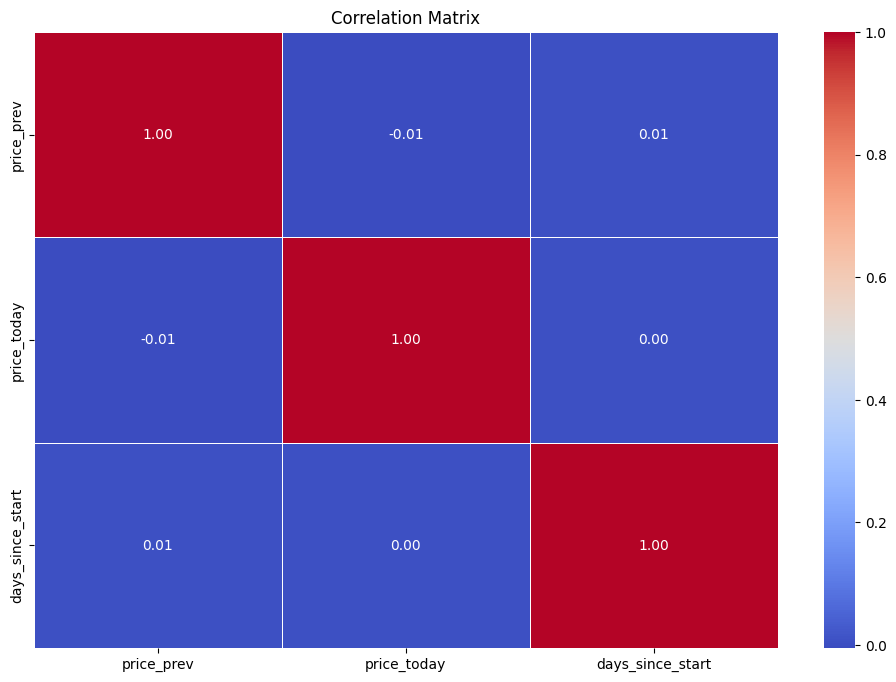

In [5]:
# Handle missing values - forward fill for time-series data
data.ffill(inplace=True)

# Convert 'report_date' to datetime and create a numeric feature (e.g., days since the first date)
data['report_date'] = pd.to_datetime(data['report_date'])
data['days_since_start'] = (data['report_date'] - data['report_date'].min()).dt.days

# Drop non-numeric columns that can't be used in correlation (e.g., 'report_date', 'special_notes', etc.)
numeric_data = data.select_dtypes(include=[np.number])

# Calculate the correlation matrix for numeric columns only
correlation_matrix = numeric_data.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Optionally, visualize the correlation matrix using a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

# 5.Encode categorical variables

In [6]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode 'market' column
data['market_encoded'] = label_encoder.fit_transform(data['market'])
print("Label Encoding for 'market' successful.")

# Encode 'item_standard' column
data['item_standard_encoded'] = label_encoder.fit_transform(data['item_standard'])
print("Label Encoding for 'item_standard' successful.")

# Encode 'price_type' column
data['price_type_encoded'] = label_encoder.fit_transform(data['price_type'])
print("Label Encoding for 'price_type' successful.")

# Encode 'category' column
data['category_encoded'] = label_encoder.fit_transform(data['category'])
print("Label Encoding for 'category' successful.")

# Encode 'origin_type' column
data['origin_type_encoded'] = label_encoder.fit_transform(data['origin_type'])
print("Label Encoding for 'origin_type' successful.")


Label Encoding for 'market' successful.
Label Encoding for 'item_standard' successful.
Label Encoding for 'price_type' successful.
Label Encoding for 'category' successful.
Label Encoding for 'origin_type' successful.


# 6. Feature Engineering

In [7]:
import warnings
import pandas as pd
import numpy as np

# Suppress RuntimeWarnings related to display formatting
warnings.simplefilter(action='ignore', category=RuntimeWarning)

# Load the dataset
data = pd.read_csv('/kaggle/input/agrisense-dataset/full_price_data.csv')

# Handle missing values - forward fill for time-series data
data.ffill(inplace=True)

# Remove any invalid or extreme values that could cause issues
data = data.replace([np.inf, -np.inf], np.nan)  # Replace infinities with NaN
data = data.dropna()  # Drop any rows with NaN values to avoid issues in the following steps

# Convert 'report_date' column to datetime
data['report_date'] = pd.to_datetime(data['report_date'], errors='coerce')  # 'coerce' will turn invalid dates to NaT (Not a Time)
print("After converting 'report_date' to datetime:")
print(data.head())  # Display the first few rows to see the 'report_date' conversion

# Create time-based features (day, month, weekday)
data['day'] = data['report_date'].dt.day
data['month'] = data['report_date'].dt.month
data['weekday'] = data['report_date'].dt.weekday
print("\nAfter creating time-based features (day, month, weekday):")
print(data.head())  # Display the first few rows to check time-based features

# Create lag features - Price of the previous day
data['lag_price'] = data.groupby('item_standard')['price_today'].shift(1)
print("\nAfter creating lag features (lag_price):")
print(data.head())  # Display the first few rows to check the 'lag_price'

# Create rolling average features - 5-day rolling average
data['rolling_avg_5'] = data.groupby('item_standard')['price_today'].rolling(window=5).mean().reset_index(0, drop=True)
print("\nAfter creating rolling average features (rolling_avg_5):")
print(data.head())  # Display the first few rows to check the 'rolling_avg_5'

# Drop rows with NaN values in lag and rolling features
data.dropna(subset=['lag_price', 'rolling_avg_5'], inplace=True)
print("\nAfter dropping rows with NaN values in 'lag_price' and 'rolling_avg_5':")
print(data.head())  # Display the first few rows after dropping NaNs


After converting 'report_date' to datetime:
   report_date category           item_raw item_standard origin_type  \
28  2017-09-12     Rice              Samba         Samba       Local   
29  2017-09-12     Rice               Nadu          Nadu       Local   
30  2017-09-12     Rice     Kekulu (White)        Kekulu       Local   
31  2017-09-12     Rice       Kekulu (Red)        Kekulu       Local   
32  2017-09-12     Rice  Ponni Samba (Imp)   Ponni Samba         Imp   

   price_type       market  unit_raw  unit_std currency  \
28     Retail       Pettah    Rs./Kg    Rs./Kg      LKR   
29  Wholesale  Narahenpita  Rs./Each  Rs./Each      LKR   
30  Wholesale   Peliyagoda  Rs./Each  Rs./Each      LKR   
31     Retail       Pettah    Rs./Kg    Rs./Kg      LKR   
32  Wholesale     Dambulla   Rs./Ltr   Rs./Ltr      LKR   

          prev_window_label  price_prev today_label  price_today  \
28  Previous 5 Days Average      162.03      12-Sep       286.78   
29                Yesterday     

# 7. Display Class Distributions

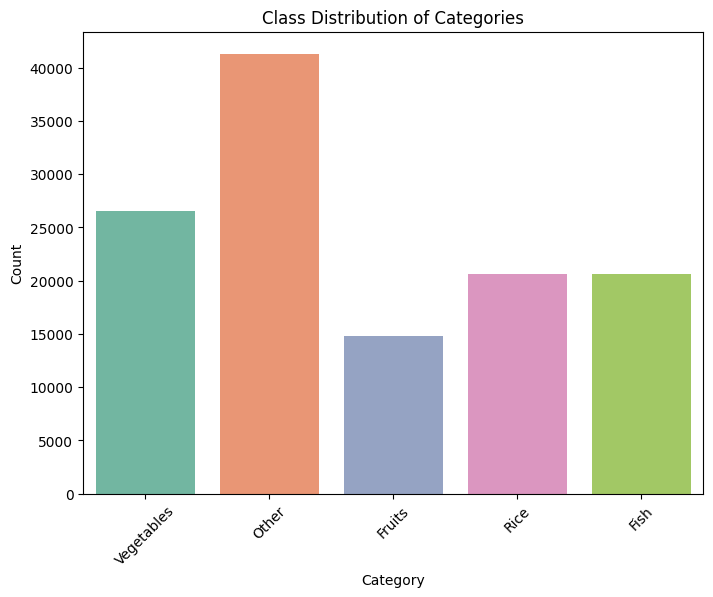

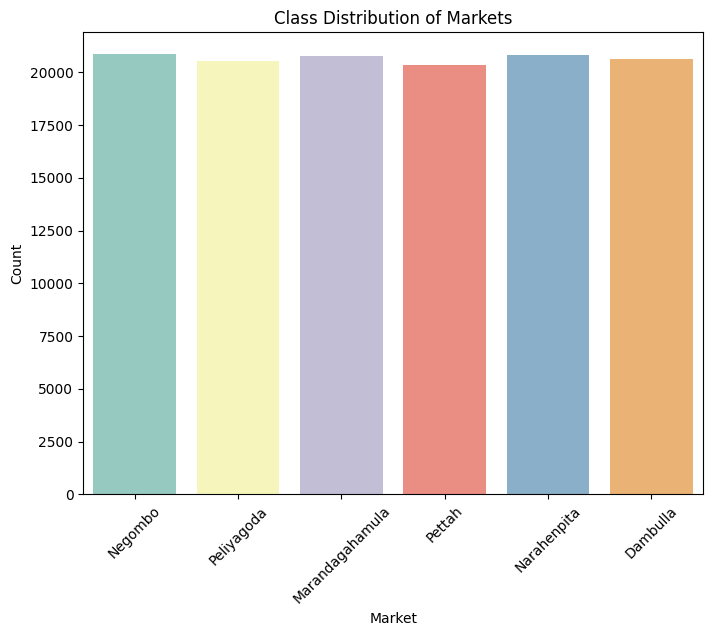

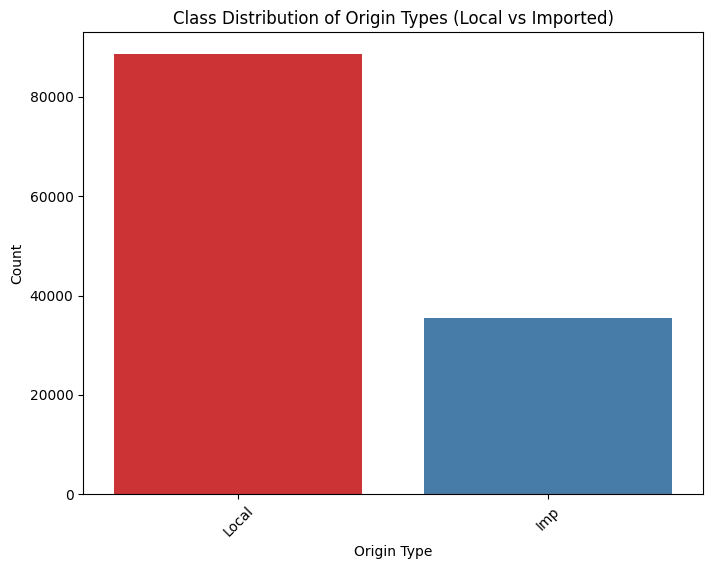

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('/kaggle/input/agrisense-dataset/full_price_data.csv')

# Handle missing values - forward fill for time-series data
data.ffill(inplace=True)

# Plot the distribution of 'category'
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='category', palette='Set2')
plt.title('Class Distribution of Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Plot the distribution of 'market'
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='market', palette='Set3')
plt.title('Class Distribution of Markets')
plt.xlabel('Market')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Plot the distribution of 'origin_type'
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='origin_type', palette='Set1')
plt.title('Class Distribution of Origin Types (Local vs Imported)')
plt.xlabel('Origin Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# 8. Defining Features and Target

In [9]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder

# Handle missing values - forward fill for time-series data
data.ffill(inplace=True)

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode all categorical columns in one go
data['market_encoded'] = label_encoder.fit_transform(data['market'])
data['item_standard_encoded'] = label_encoder.fit_transform(data['item_standard'])
data['price_type_encoded'] = label_encoder.fit_transform(data['price_type'])
data['category_encoded'] = label_encoder.fit_transform(data['category'])
data['origin_type_encoded'] = label_encoder.fit_transform(data['origin_type'])

print("Label Encoding completed for all columns.")

# Save the trained LabelEncoder to a file
label_encoder_path = '/kaggle/working/label_encoder.pkl'
joblib.dump(label_encoder, label_encoder_path)
print(f"LabelEncoder saved at: {label_encoder_path}")

# To confirm, load and display the saved LabelEncoder
loaded_label_encoder = joblib.load(label_encoder_path)
print("\nLabelEncoder loaded successfully:")
print(loaded_label_encoder.classes_)

# Ensure that the necessary columns exist in the DataFrame
required_columns = ['market_encoded', 'item_standard_encoded', 'price_type_encoded', 'category_encoded', 'origin_type_encoded', 
                    'day', 'month', 'weekday', 'lag_price', 'rolling_avg_5', 'price_today']

# Check for any missing columns
missing_columns = [col for col in required_columns if col not in data.columns]
if missing_columns:
    print(f"Missing columns: {missing_columns}")
else:
    print("All required columns are present.")

# Create time-based features (day, month, weekday) if not already created
if 'day' not in data.columns:
    data['report_date'] = pd.to_datetime(data['report_date'], errors='coerce')
    data['day'] = data['report_date'].dt.day
    data['month'] = data['report_date'].dt.month
    data['weekday'] = data['report_date'].dt.weekday
    print("Time-based features (day, month, weekday) created successfully.")

# Create lag features - Price of the previous day
if 'lag_price' not in data.columns:
    data['lag_price'] = data.groupby('item_standard')['price_today'].shift(1)
    print("Lag features ('lag_price') created successfully.")

# Create rolling average features - 5-day rolling average
if 'rolling_avg_5' not in data.columns:
    data['rolling_avg_5'] = data.groupby('item_standard')['price_today'].rolling(window=5).mean().reset_index(0, drop=True)
    print("Rolling average features ('rolling_avg_5') created successfully.")

# Drop rows with NaN values in lag and rolling features
data.dropna(subset=['lag_price', 'rolling_avg_5'], inplace=True)
print("Rows with NaN values in 'lag_price' and 'rolling_avg_5' have been dropped.")

# Define features and target
features = ['market_encoded', 'item_standard_encoded', 'price_type_encoded', 'category_encoded', 'origin_type_encoded', 
            'day', 'month', 'weekday', 'lag_price', 'rolling_avg_5']
target = 'price_today'  # This is the price we want to predict

X = data[features]  # Feature matrix
y = data[target]    # Target vector

# Display the first few rows of features and target for verification
print("\nFeature Matrix (X) and Target (y):")
print(X.head())
print(y.head())

Label Encoding completed for all columns.
LabelEncoder saved at: /kaggle/working/label_encoder.pkl

LabelEncoder loaded successfully:
['Imp' 'Local']
Missing columns: ['day', 'month', 'weekday', 'lag_price', 'rolling_avg_5']
Time-based features (day, month, weekday) created successfully.
Lag features ('lag_price') created successfully.
Rolling average features ('rolling_avg_5') created successfully.
Rows with NaN values in 'lag_price' and 'rolling_avg_5' have been dropped.

Feature Matrix (X) and Target (y):
    market_encoded  item_standard_encoded  price_type_encoded  \
73               0                     15                   1   
76               3                     15                   1   
93               4                     28                   0   
94               3                     28                   1   
95               5                      4                   1   

    category_encoded  origin_type_encoded  day  month  weekday  lag_price  \
73                

# 9. Splitting the Data into Training and Testing Sets

In [10]:
from sklearn.model_selection import train_test_split

# Define features and target (if not defined earlier)
features = ['market_encoded', 'item_standard_encoded', 'price_type_encoded', 'category_encoded', 'origin_type_encoded', 
            'day', 'month', 'weekday', 'lag_price', 'rolling_avg_5']
target = 'price_today'  # This is the price we want to predict

X = data[features]  # Feature matrix
y = data[target]    # Target vector

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Display the shape of training and testing sets
print("\nTraining set shape (X_train, y_train):")
print(X_train.shape, y_train.shape)

print("\nTesting set shape (X_test, y_test):")
print(X_test.shape, y_test.shape)



Training set shape (X_train, y_train):
(99072, 10) (99072,)

Testing set shape (X_test, y_test):
(24768, 10) (24768,)


# 10. LightGBM Model Training

In [11]:
!pip install --upgrade lightgbm


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002425 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 613
[LightGBM] [Info] Number of data points in the train set: 99072, number of used features: 10
[LightGBM] [Info] Start training from score 300.066201
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[193]	train's l1: 82.2088	test's l1: 82.9669
Mean Absolute Error (MAE): 82.9669242706424


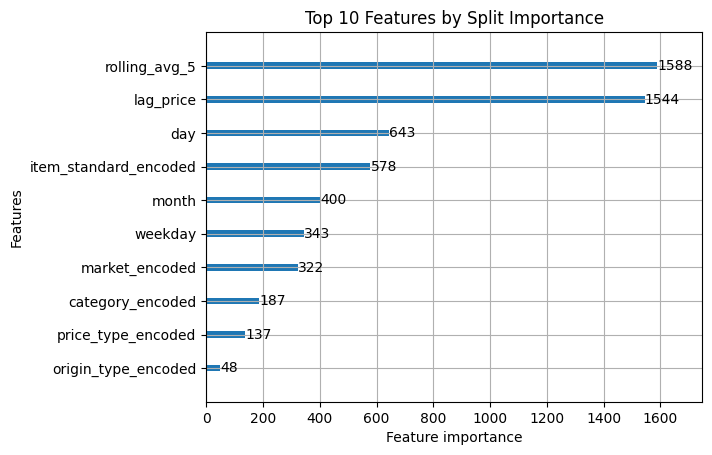

LightGBM model saved at: /kaggle/working/price_prediction_model.txt


In [12]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Set up LightGBM model parameters
params = {
    'objective': 'regression',  # We're predicting a continuous value (price)
    'metric': 'mae',            # Mean Absolute Error (MAE) as evaluation metric
    'boosting_type': 'gbdt',    # Gradient Boosting Decision Tree
    'num_leaves': 31,           # Number of leaves in the tree
    'learning_rate': 0.05,      # Learning rate
    'feature_fraction': 0.9     # Fraction of features to use in each boosting round
}

# Convert training and test data into LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Define early stopping criteria
early_stopping = lgb.callback.early_stopping(stopping_rounds=50, verbose=True)

# Train the LightGBM model with early stopping using callbacks
model = lgb.train(
    params, 
    train_data, 
    num_boost_round=1000, 
    valid_sets=[train_data, test_data],  # Provide both train and validation sets
    valid_names=['train', 'test'],       # Names for the datasets
    callbacks=[early_stopping]           # Use early stopping callback
)

# Make predictions
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')

# Plot the feature importance
lgb.plot_importance(model, max_num_features=10, importance_type='split')
plt.title('Top 10 Features by Split Importance')
plt.show()

# Save the trained model if needed
model.save_model('/kaggle/working/price_prediction_model.txt')
print("LightGBM model saved at: /kaggle/working/price_prediction_model.txt")


# 11. Model Prediction and Evaluation

Mean Absolute Error (MAE): 82.9669242706424
Mean Squared Error (MSE): 9942.34373788333
Root Mean Squared Error (RMSE): 99.71130195661537
R-squared (R²): 0.25644498071280086


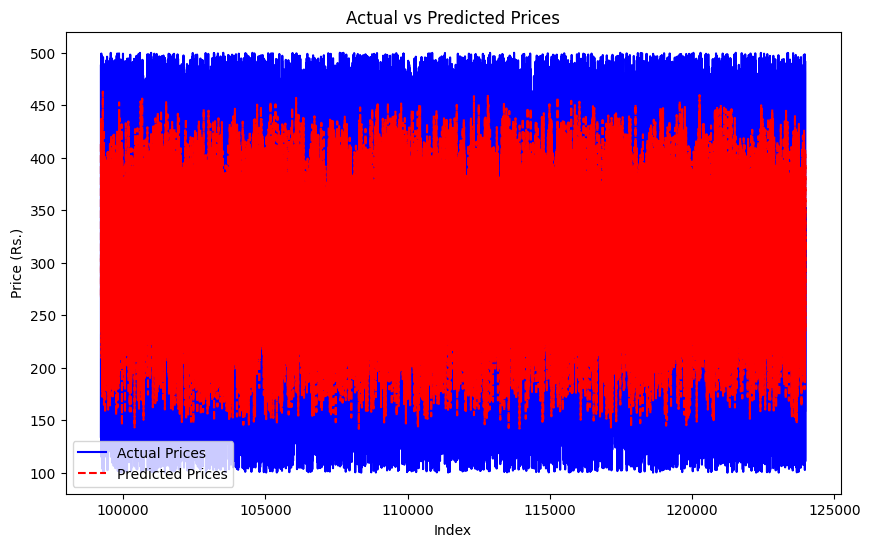

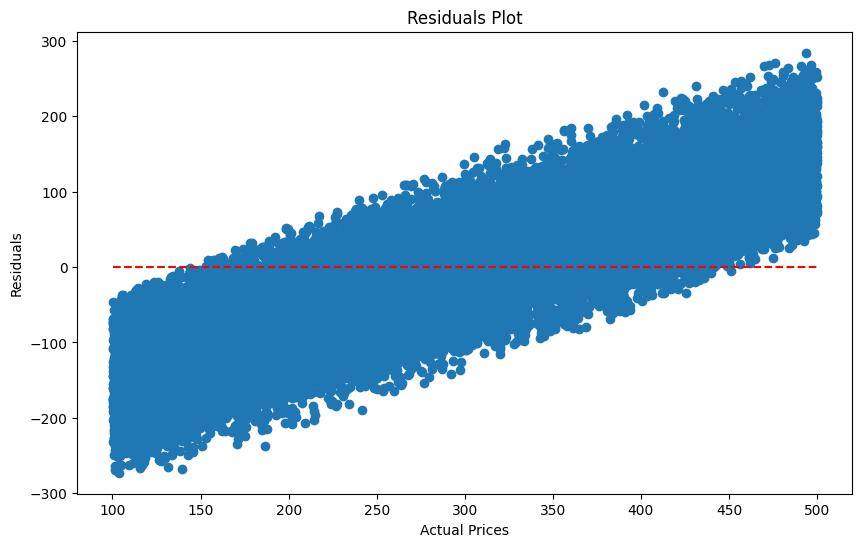

Predictions saved at: /kaggle/working/predictions.csv


In [13]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Make predictions
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

# 1. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')

# 2. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error (MSE): {mse}')

# 3. Root Mean Squared Error (RMSE)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f'Root Mean Squared Error (RMSE): {rmse}')

# 4. R-squared (R²)
r2 = r2_score(y_test, y_pred)
print(f'R-squared (R²): {r2}')

# 5. Prediction vs Actual Plot
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, y_test.values, label='Actual Prices', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted Prices', color='red', linestyle='--')
plt.legend()
plt.title('Actual vs Predicted Prices')
plt.xlabel('Index')
plt.ylabel('Price (Rs.)')
plt.show()

# Optionally, plot the residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuals)
plt.hlines(y=0, xmin=y_test.min(), xmax=y_test.max(), colors='red', linestyles='dashed')
plt.title('Residuals Plot')
plt.xlabel('Actual Prices')
plt.ylabel('Residuals')
plt.show()

# Optionally, save the predictions to a CSV file
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
predictions_df.to_csv('/kaggle/working/predictions.csv', index=False)
print("Predictions saved at: /kaggle/working/predictions.csv")


# 12. Saving the Model

In [14]:
# Save the trained model if needed
model.save_model('/kaggle/working/price_prediction_model.txt')
print("LightGBM model saved at: /kaggle/working/price_prediction_model.txt")

LightGBM model saved at: /kaggle/working/price_prediction_model.txt


# 13. Model Testing

In [15]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder

# Load the trained model
model = lgb.Booster(model_file='/kaggle/working/price_prediction_model.txt')

# Example new input data (replace with your actual test inputs)
new_data = pd.DataFrame({
    'market': ['Pettah'],  # Replace with actual market names
    'item_standard': ['Beans'],  # Replace with actual item names
    'price_type': ['Wholesale'],  # 'Wholesale' or 'Retail'
    'category': ['Vegetables'],  # 'Vegetables' / 'Fruits' / 'Rice'
    'origin_type': ['Local'],  # 'Local' / 'Imp'
    'day': [10],  # Day of the month (e.g., 10)
    'month': [10],  # Month (e.g., 10)
    'weekday': [2],  # Weekday (e.g., Monday = 0, Sunday = 6)
    'lag_price': [81.0],  # Previous day's price (this should be calculated based on historical data)
    'rolling_avg_5': [80.0]  # 5-day rolling average price
})

# Encode the categorical columns for the new data (use the same LabelEncoder as during training)
label_encoder = LabelEncoder()

# Note: In a real-world scenario, you should load the same LabelEncoder used during training
new_data['market_encoded'] = label_encoder.fit_transform(new_data['market'])
new_data['item_standard_encoded'] = label_encoder.fit_transform(new_data['item_standard'])
new_data['price_type_encoded'] = label_encoder.fit_transform(new_data['price_type'])
new_data['category_encoded'] = label_encoder.fit_transform(new_data['category'])
new_data['origin_type_encoded'] = label_encoder.fit_transform(new_data['origin_type'])

# Features used for prediction (must be the same as during training)
features = ['market_encoded', 'item_standard_encoded', 'price_type_encoded', 'category_encoded', 'origin_type_encoded',
            'day', 'month', 'weekday', 'lag_price', 'rolling_avg_5']

# Extract the feature data for prediction
X_new = new_data[features]

# Predict using the trained model
y_pred = model.predict(X_new)

# Let's assume the standard deviation of the prediction is known or estimated from training
# For simplicity, we'll assume a small error range (you can use model predictions from a validation set or Bootstrap for a more realistic prediction interval).
# In reality, LightGBM does not output prediction intervals directly, so we estimate based on variance.

prediction_interval = 0.1  # Assuming 10% uncertainty (for demonstration purposes)
lower_bound = y_pred[0] * (1 - prediction_interval)
upper_bound = y_pred[0] * (1 + prediction_interval)

# Price Trend: Compare predicted price to lagged price (or moving average) to identify trend
previous_price = new_data['lag_price'].values[0]  # or use a moving average instead
if y_pred[0] > previous_price:
    price_trend = "↑ increase"
elif y_pred[0] < previous_price:
    price_trend = "↓ decrease"
else:
    price_trend = "≈ stable"

# Demand Index: We create a simple placeholder for demand index
# Here, we'll assume that a higher price variability (difference between predicted and lag price) means higher demand
demand_index = abs(y_pred[0] - previous_price) / previous_price  # Basic demand index (higher variability = higher demand)

# Confidence Score: Based on the difference between predicted price and the 95% confidence range (assuming normal distribution)
confidence_score = 1 - prediction_interval  # Simplified version of confidence (use a more complex method in real cases)

# Output the results
print(f"Predicted Price: {y_pred[0]:.2f} Rs.")
print(f"Price Range: {lower_bound:.2f} Rs. - {upper_bound:.2f} Rs. (P10-P90)")
print(f"Price Trend: {price_trend}")
print(f"Demand Index: {demand_index:.4f}")
print(f"Confidence Score: {confidence_score:.2f}")


Predicted Price: 179.65 Rs.
Price Range: 161.69 Rs. - 197.62 Rs. (P10-P90)
Price Trend: ↑ increase
Demand Index: 1.2179
Confidence Score: 0.90
